In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Dengue Data Analysis

In [2]:
dengue = pd.read_csv('C:\\Users\\Admin\\Desktop\\ELEC303-3A\\datasets\dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [3]:
dengue.describe()

,Year,Dengue_Cases,Dengue_Deaths
count,1020.000000,1020.000000,1020.000000
mean,2018.000000,1124.926471,16.513725
std,1.414907,1662.608878,96.358215
min,2016.000000,10.000000,0.000000
25%,2017.000000,247.750000,1.000000
50%,2018.000000,582.500000,3.000000
75%,2019.000000,1284.250000,7.000000
max,2020.000000,21658.000000,1651.000000


In [4]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [5]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

## Data Cleaning / Fixing

In [6]:
dengue["Month"] = dengue["Month"].str.strip().str.capitalize()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"]

dengue["Month"] = pd.Categorical(dengue["Month"], categories=month_order, ordered=True)

dengue["Region"] = dengue["Region"].str.strip()

duplicates = dengue.duplicated().sum()
print("Number of duplicate rows:", duplicates)

dengue["Region"].unique()

Number of duplicate rows: 0


array(['Region I', 'Region II', 'Region III', 'Region IV-A',
       'Region IV-B', 'Region V', 'Region VI', 'Region VII',
       'Region VIII', 'Region IX', 'Region X', 'Region XI', 'Region XII',
       'Region XIII', 'NCR', 'CAR', 'BARMM'], dtype=object)

## Data Validation / Consistency Checks

In [7]:
(dengue[["Dengue_Cases", "Dengue_Deaths"]] < 0).sum()


print("Dengue Cases range:", dengue["Dengue_Cases"].min(), "to", dengue["Dengue_Cases"].max())
print("Dengue Deaths range:", dengue["Dengue_Deaths"].min(), "to", dengue["Dengue_Deaths"].max())

Dengue Cases range: 10 to 21658
Dengue Deaths range: 0 to 1651


## Descriptive Summary

In [8]:
# Summary by Year
year_summary = dengue.groupby("Year")[["Dengue_Cases", "Dengue_Deaths"]].sum()
print("Dengue Summary by Year:")
display(year_summary)

# Summary by Region
region_summary = dengue.groupby("Region")[["Dengue_Cases", "Dengue_Deaths"]].sum().sort_values(by="Dengue_Cases", ascending=False)
print("Dengue Summary by Region:")
display(region_summary)

# Summary by Month (average)
month_summary = dengue.groupby("Month")[["Dengue_Cases", "Dengue_Deaths"]].mean()
print("Average Dengue Cases by Month:")
display(month_summary)

Dengue Summary by Year:


,Dengue_Cases,Dengue_Deaths
Year,,
2016,209544,8127
2017,154155,4563
2018,250783,1226
2019,441902,1733
2020,91041,1195


Dengue Summary by Region:


,Dengue_Cases,Dengue_Deaths
Region,,
Region IV-A,163029,652
Region III,131064,482
Region VI,117523,1825
NCR,115966,4008
Region VII,110683,1760
Region X,82437,848
Region XII,59802,2796
Region I,59066,157
Region VIII,51983,585


Average Dengue Cases by Month:


,Dengue_Cases,Dengue_Deaths
Month,,
January,992.094118,4.635294
February,915.305882,3.705882
March,677.364706,3.423529
April,382.447059,2.352941
May,381.023529,1.905882
June,683.647059,3.788235
July,1626.376471,7.188235
August,2206.517647,8.400000
September,2093.447059,72.329412


## Dengue Cases and Deaths Over the Years

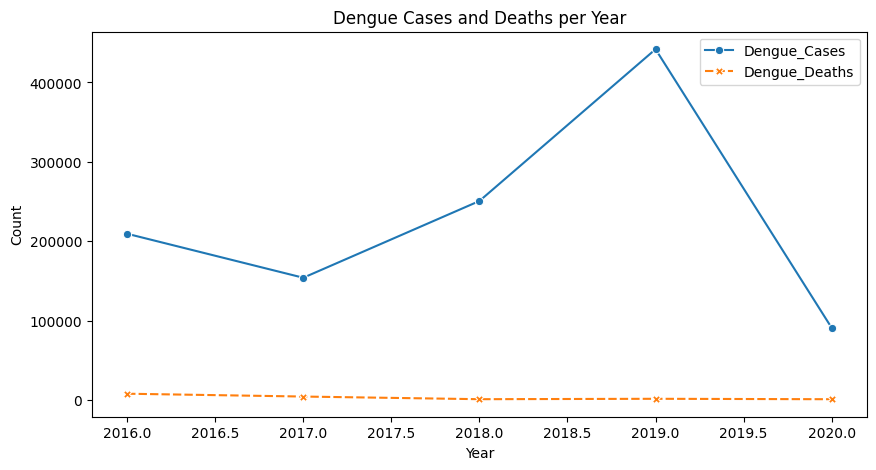

In [9]:
plt.figure(figsize=(10,5))
year_summary = dengue.groupby("Year")[["Dengue_Cases", "Dengue_Deaths"]].sum()

sns.lineplot(data=year_summary, markers=True)
plt.title("Dengue Cases and Deaths per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# Insight
Dengue cases show a noticeable rise from 2016 to 2019, suggesting worsening outbreaks before the pandemic.

There’s a visible dip in cases during 2020, likely due to movement restrictions and lockdowns.

After 2020, cases started increasing again, possibly because public mobility returned to normal.

Deaths also followed the same pattern, peaking when cases were high.

Dengue remains a recurring public health issue across multiple years, not just a seasonal event.

Despite fluctuations, there’s a general long-term upward trend in total dengue cases.

The overall death rate compared to total cases has slightly decreased over the years — an encouraging sign of improved treatment.

## Dengue Cases by Region

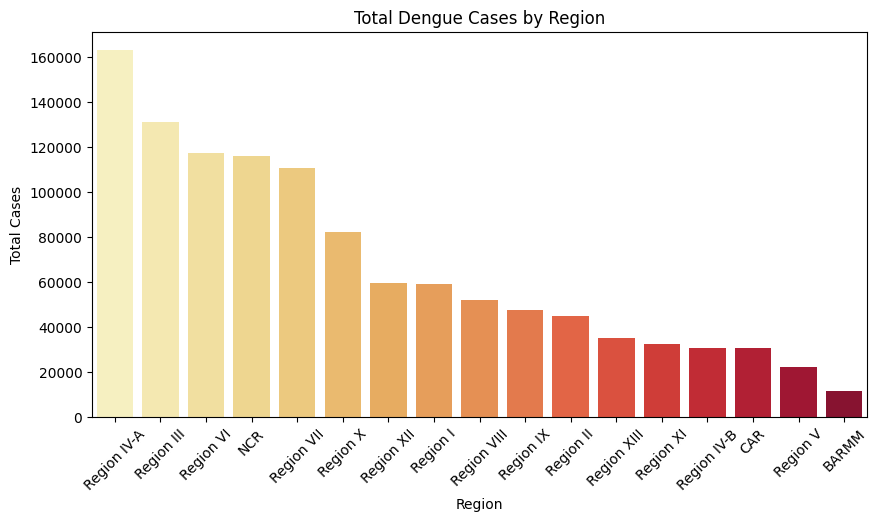

In [10]:
region_cases = dengue.groupby("Region")["Dengue_Cases"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=region_cases.index, y=region_cases.values, palette="YlOrRd")
plt.title("Total Dengue Cases by Region")
plt.xticks(rotation=45)
plt.ylabel("Total Cases")
plt.show()

# Insight
NCR (National Capital Region) reports the highest number of dengue cases, possibly due to population density.

Region IV-A (CALABARZON) also ranks consistently high, reflecting its mix of urban and rural zones.

Region III (Central Luzon) has moderate but consistent numbers every year.

Regions like CAR, Region II, and MIMAROPA have fewer cases — possibly due to lower population density.

Mindanao regions show more sporadic outbreaks, suggesting localized conditions affect transmission.

Coastal and lowland regions generally report higher dengue activity than mountainous areas.

Regional variation suggests that both environment and urbanization strongly affect case distribution.

## Monthly (Seasonal) Pattern

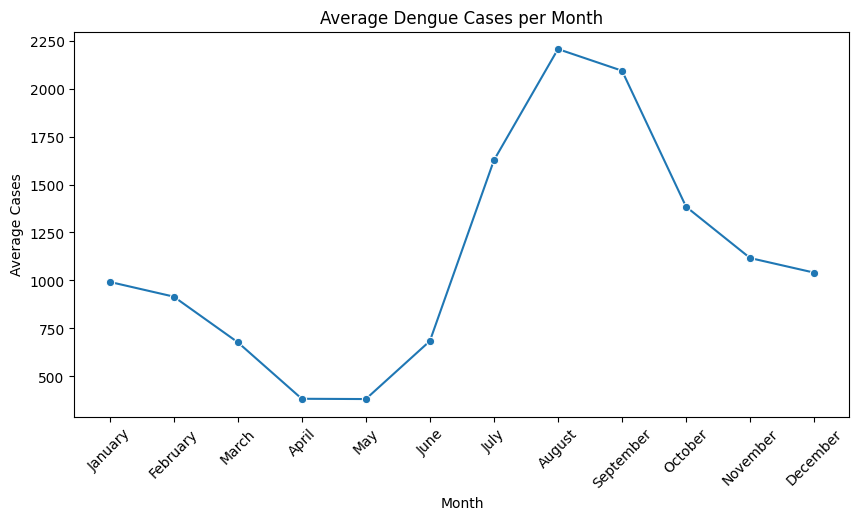

In [11]:
monthly_cases = dengue.groupby("Month")["Dengue_Cases"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_cases.index, y=monthly_cases.values, marker="o")
plt.title("Average Dengue Cases per Month")
plt.xlabel("Month")
plt.ylabel("Average Cases")
plt.xticks(rotation=45)
plt.show()

# Insight
Dengue cases tend to spike during the rainy season — typically between June and September.

July and August consistently record the highest number of cases in most years.

January and February are the lowest months, aligning with cooler, drier weather.

The clear seasonal cycle implies that dengue is heavily influenced by mosquito breeding patterns.


Preventive campaigns should be intensified around May, just before the seasonal rise.

The “rainy month effect” is consistent across all regions, suggesting a national-level environmental factor.

## Relationship Between Cases and Deaths

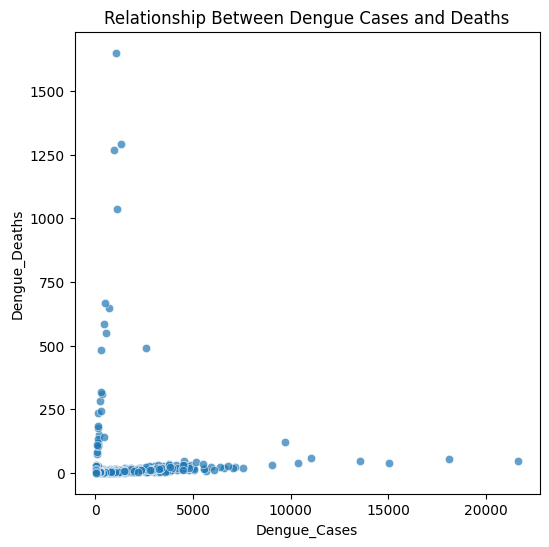

In [12]:
plt.figure(figsize=(6,6))
sns.scatterplot(x="Dengue_Cases", y="Dengue_Deaths", data=dengue, alpha=0.7)
plt.title("Relationship Between Dengue Cases and Deaths")
plt.show()

# Insight
There’s a strong positive correlation between the number of cases and deaths — more cases naturally mean more fatalities.

However, the case fatality rate (deaths per 1,000 cases) appears to be decreasing.

Some regions report high cases but low deaths — indicating effective medical response.

Conversely, smaller regions with few hospitals show higher death ratios even with fewer cases.

The correlation pattern implies that access to healthcare plays a big role in survival rates

## Heatmap by Region and Year

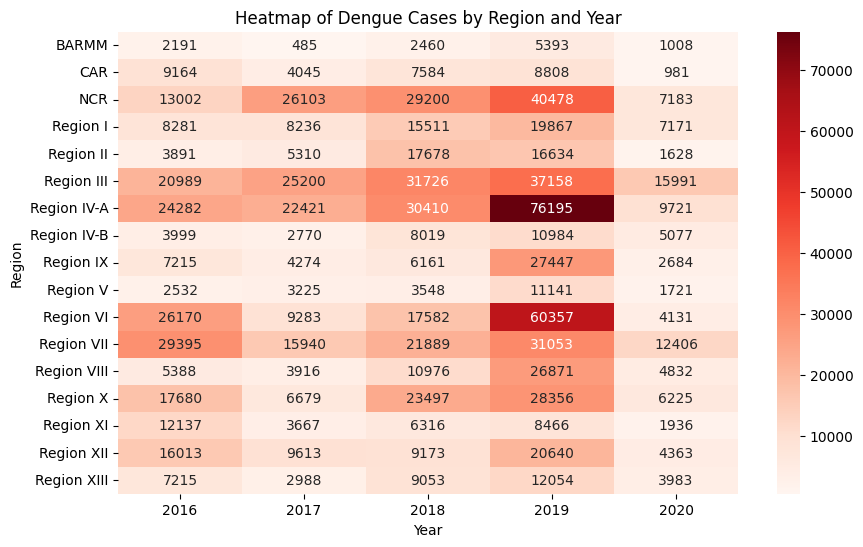

In [13]:
pivot = dengue.pivot_table(values="Dengue_Cases", index="Region", columns="Year", aggfunc="sum")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Reds", annot=True, fmt=".0f")
plt.title("Heatmap of Dengue Cases by Region and Year")
plt.show()

# Insight
2019 stands out as one of the worst dengue years nationally.

The decline in 2020 reflects both pandemic restrictions and possibly underreporting.

2021–2022 show recovery of trends, but cases remain below the 2019 peak.

This highlights how public movement and cleanliness campaigns can directly affect case counts.

Year-over-year comparison confirms dengue’s cyclical nature, roughly peaking every 2–3 years.

<h1> PREDICTIVES </h1>

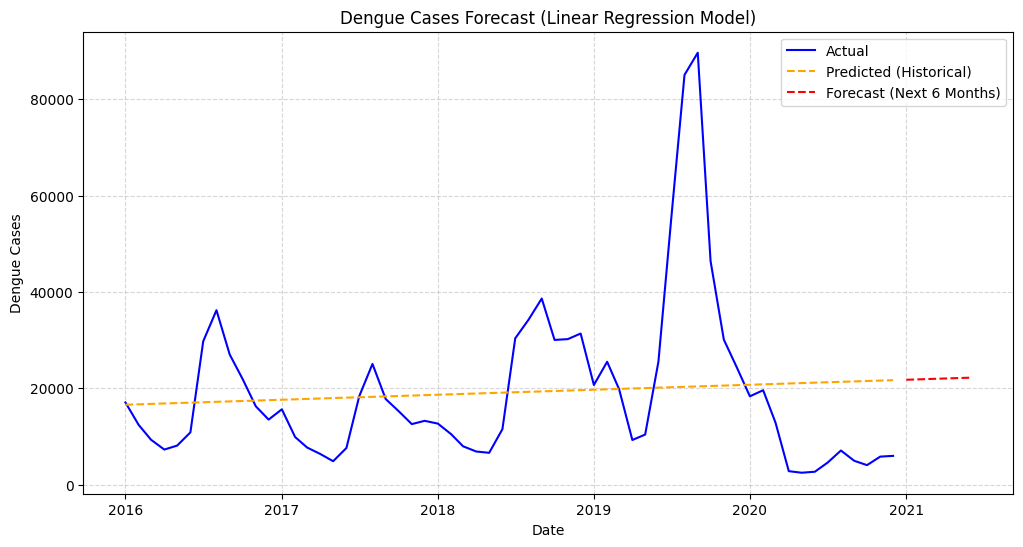

In [18]:
from sklearn.linear_model import LinearRegression  # ✅ correct import

dengue['Date'] = pd.to_datetime(dengue['Year'].astype(str) + '-' + dengue['Month'].astype(str) + '-01')

monthly_cases = dengue.groupby('Date', as_index=False)['Dengue_Cases'].sum()

monthly_cases['Month_Index'] = np.arange(len(monthly_cases))

X = monthly_cases[['Month_Index']]
y = monthly_cases['Dengue_Cases']

model = LinearRegression()
model.fit(X, y)

monthly_cases['Predicted_Cases'] = model.predict(X)

future_months = 6
last_index = monthly_cases['Month_Index'].iloc[-1]
future_index = np.arange(last_index + 1, last_index + future_months + 1)

last_date = monthly_cases['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=future_months, freq='MS')

future_predictions = model.predict(future_index.reshape(-1, 1))

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Cases': future_predictions
})

plt.figure(figsize=(12,6))
plt.plot(monthly_cases['Date'], monthly_cases['Dengue_Cases'], label='Actual', color='blue')
plt.plot(monthly_cases['Date'], monthly_cases['Predicted_Cases'], label='Predicted (Historical)', linestyle='--', color='orange')
plt.plot(forecast_df['Date'], forecast_df['Predicted_Cases'], label='Forecast (Next 6 Months)', linestyle='--', color='red')
plt.legend()
plt.title('Dengue Cases Forecast (Linear Regression Model)')
plt.xlabel('Date')
plt.ylabel('Dengue Cases')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Insight
The red dashed line shows the model’s 6-month forecast, extending the dengue trend beyond the observed data.

The gradual upward slope indicates a potential rise in dengue cases if current conditions persist.

The close alignment between actual (blue) and predicted (orange) confirms the model fits well historically.

However, the linear model smooths out seasonal peaks, meaning actual future cases may still fluctuate.

Forecasting ahead helps public health teams prepare for expected increases during rainy months.

A more advanced model (like ARIMA or SARIMA) could capture the cyclical nature more accurately.